# Revision analyses — MRAN-D-26-00103

**A Markov chain Monte Carlo framework for exploring parameter dynamics under repeated thermal inactivation**

This notebook contains **only the NEW analyses required by the three MRA reviewers**.
Run it *after* (or alongside) `Multiple_heating_and_revolution.ipynb` — it re-uses the same
`.pkl` files and reproduces the published run exactly when all knobs are left at their defaults.

| Part | Analysis | Reviewer comment addressed |
|------|----------|---------------------------|
| 1 | δ-parameterisation: verification + generalisation to any log-target | **R3** (Lines 133–136) — *the equation error* |
| 2 | Algorithm validation: stationary distribution = MVN_inter | **R1** (prove the simulation is correct) |
| 3 | Sensitivity to **intra**-strain covariance | **R3** (main request), **R2** (L156) |
| 4 | Sensitivity to **inter**-strain covariance | **R2** (L156) |
| 5 | Sensitivity to carry-over parameter **n** | **R2** (L214) |
| 6 | Sensitivity to likelihood-ratio exponent **L_para** | **R3** (found it in the code!) |
| 7 | Monte-Carlo replicate-number convergence | **R1** (rigour) |
| 8 | Quantitative convergence rates | **R2/R3** |
| 9 | Comparison with Berdejo et al. (2024) at 10 cycles | **R1** (external evidence) |
| 10 | QMRA linkage — risk estimates change | **R3** (*"more evolution than risk assessment"*) |

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, scipy as sp
import matplotlib.pyplot as plt, seaborn as sns, pickle, warnings
from scipy import stats
warnings.simplefilter('ignore', RuntimeWarning)

from revision_core import (heat_rev_general, run_batch, summarise, final_params,
                           convergence_cycle, log_reduction, time_for_reduction)

samples   = pickle.load(open('Samples extracted modfied Weibull multi-level MVN stan.pkl','rb'))
n_post    = samples['Paras0_between'].shape[0]

# published settings
SIM_NUM   = 10000
REVO_NUM  = 100
CELL      = 10**4          # N_cell = 4-log regrowth
NPROC     = 6
ATCC      = np.log([1.80, 1.17])          # ATCC 33560

delta0_mean = np.exp(np.mean(samples['logdelta0_between']))
power0_mean = np.exp(np.mean(samples['logpower0_between'])) \
              if 'logpower0_between' in samples else np.exp(samples['Paras0_between'][:,1].mean())

T = {'none': 0.0, '2log': 2*delta0_mean, '4log': 4*delta0_mean, '6log': 6*delta0_mean}
print(f'delta_mean = {delta0_mean:.3f} min   p_mean = {power0_mean:.3f}')
print({k: round(v,2) for k,v in T.items()})

delta_mean = 1.296 min   p_mean = 1.024
{'none': 0.0, '2log': 2.59, '4log': 5.18, '6log': 7.77}


---
## Part 1 — δ-parameterisation: verification and generalisation
### → Reviewer #3, Lines 133–136 (**the most important single item**)

The reviewer is **right**. In

$$\log_{10}N_t=\log_{10}N_0-6\left(\frac{t}{6\delta}\right)^{p}$$

the time that gives a 6-log reduction is $t=6\delta$, **not** $\delta$.
The equation and the code are **correct** — only the *sentence* in the manuscript was wrong.

The correct reading is: **$\delta$ = the mean characteristic time per one log-reduction,
averaged over a 6-log reduction**, i.e. $\delta=\delta_6/6$.

This cell (a) proves it numerically, (b) shows why the heating times $2\delta,4\delta,6\delta$ were
chosen, and (c) **generalises** the convention to any log-target, as the reviewer requested.

In [2]:
# ---- (a) t = 6*delta gives exactly 6 log for ANY p ; t = delta does not -------
rows = []
for p in [0.6, 0.8, 1.0, 1.2, 1.5, 2.0]:
    rows.append({'p': p,
                 'reduction at t=delta'  : log_reduction(1.0, 1.0, p),
                 'reduction at t=6*delta': log_reduction(6.0, 1.0, p)})
chk = pd.DataFrame(rows)
print("delta = 1 min, so 6*delta = 6 min\n")
print(chk.to_string(index=False, float_format='%.4f'))
assert np.allclose(chk['reduction at t=6*delta'], 6.0), "6*delta must give exactly 6 log"
print("\n=> t = 6*delta gives EXACTLY 6 log for every p.  delta is delta_6 / 6.  [verified]")

delta = 1 min, so 6*delta = 6 min

     p  reduction at t=delta  reduction at t=6*delta
0.6000                2.0477                  6.0000
0.8000                1.4310                  6.0000
1.0000                1.0000                  6.0000
1.2000                0.6988                  6.0000
1.5000                0.4082                  6.0000
2.0000                0.1667                  6.0000

=> t = 6*delta gives EXACTLY 6 log for every p.  delta is delta_6 / 6.  [verified]


In [3]:
# ---- (b) why 2*delta / 4*delta / 6*delta were used ---------------------------
# For p = 1 these give EXACTLY 2-, 4- and 6-log reductions.  For the actual
# posterior distribution of p they give the values tabulated below.
lnd = samples['Paras0_between'][:,0]; lnp = samples['Paras0_between'][:,1]
d_post, p_post = np.exp(lnd), np.exp(lnp)

rows = []
for k, lab in [(2,'2-log'), (4,'4-log'), (6,'6-log')]:
    t = k*delta0_mean
    R = log_reduction(t, delta0_mean, p_post)      # mean strain, posterior spread of p
    rows.append({'label': lab, 't (min)': t,
                 'achieved log-reduction (median)': np.median(R),
                 '2.5%': np.percentile(R,2.5), '97.5%': np.percentile(R,97.5)})
tab1 = pd.DataFrame(rows)
print(tab1.to_string(index=False, float_format='%.3f'))
print("\n=> the '2-log / 4-log / 6-log' labels are exact for p=1 and accurate to "
      "~0.1 log for the fitted p.  This will be stated explicitly in the revised Methods.")
tab1.to_csv('Evo_Fig/Table_S1_achieved_reductions.csv', index=False)

label  t (min)  achieved log-reduction (median)  2.5%  97.5%
2-log    2.591                            1.945 1.773  2.126
4-log    5.182                            3.959 3.826  4.091
6-log    7.774                            6.000 6.000  6.000

=> the '2-log / 4-log / 6-log' labels are exact for p=1 and accurate to ~0.1 log for the fitted p.  This will be stated explicitly in the revised Methods.


In [4]:
# ---- (c) GENERALISATION to any log-target R (Reviewer #3's request) ----------
#   t_R = 6*delta * (R/6)**(1/p)
# Sanity: R = 6 recovers t = 6*delta for any p.
for p in [0.7, 1.0, 1.4]:
    assert np.isclose(time_for_reduction(6.0, 1.0, p), 6.0)

R_grid = np.array([1,2,3,4,5,6,7,8])
gen = pd.DataFrame({'target log-reduction': R_grid,
                    't (min), mean strain': time_for_reduction(R_grid, delta0_mean, power0_mean)})
print(gen.to_string(index=False, float_format='%.3f'))
gen.to_csv('Evo_Fig/Table_S2_generalised_targets.csv', index=False)

 target log-reduction  t (min), mean strain
                    1                 1.352
                    2                 2.660
                    3                 3.951
                    4                 5.233
                    5                 6.506
                    6                 7.774
                    7                 9.036
                    8                10.294


---
## Part 2 — Algorithm validation: the chain converges to MVN$_{\rm inter}$
### → Reviewer #1 ("*provide some evidence to prove the accuracy of simulation*")

Wet-lab validation is not available, but the **algorithm itself can be validated exactly**.

With `t_heating = 0` there is no thermal selection, so every cell survives and picking one
survivor at random is a *single* Metropolis–Hastings step. The chain is then a textbook
random-walk MH sampler whose **target distribution is MVN$_{\rm inter}$** — a distribution we
know in closed form. So the model makes a *falsifiable* prediction:

> starting anywhere (e.g. from ATCC 33560), the no-heating chain must relax to
> MVN$_{\rm inter}$ and then stay there.

We test this three ways: (i) the drift of the mean, (ii) the recovered mean/covariance,
(iii) a Mahalanobis $\chi^2_2$ goodness-of-fit test. **This is the strongest validation
available without new experiments, and it is already visible in Fig. 5 (blue curves).**

In [5]:
# Fix ONE posterior draw so that the target distribution is uniquely defined.
PID = int(np.argmin(np.abs(samples['Paras0_between'][:,0] - samples['Paras0_between'][:,0].mean())))
mu_t  = samples['Paras0_between'][PID]
cov_t = samples['cov_between'][PID]
print('target mean :', np.round(mu_t,4))
print('target cov  :\n', np.round(cov_t,5))

# (i) start FAR from the target (ATCC 33560) with NO heating -> must relax to target
val_atcc = run_batch(samples, t_heating=0.0, sim_num=2000, processor_num=NPROC,
                     revo_num=400, cell_count=CELL, n_carry=1, L_para=1.0,
                     init_mode='fixed', init_logpara=ATCC, posterior_id=PID)
# (ii) start FROM the target -> must stay (stationarity)
val_inter = run_batch(samples, t_heating=0.0, sim_num=2000, processor_num=NPROC,
                      revo_num=400, cell_count=CELL, n_carry=1, L_para=1.0,
                      init_mode='inter', posterior_id=PID)

s_atcc  = summarise(val_atcc,  revo_num=400)
s_inter = summarise(val_inter, revo_num=400)

target mean : [0.259  0.0053]
target cov  :
 [[ 0.06659 -0.03597]
 [-0.03597  0.09372]]


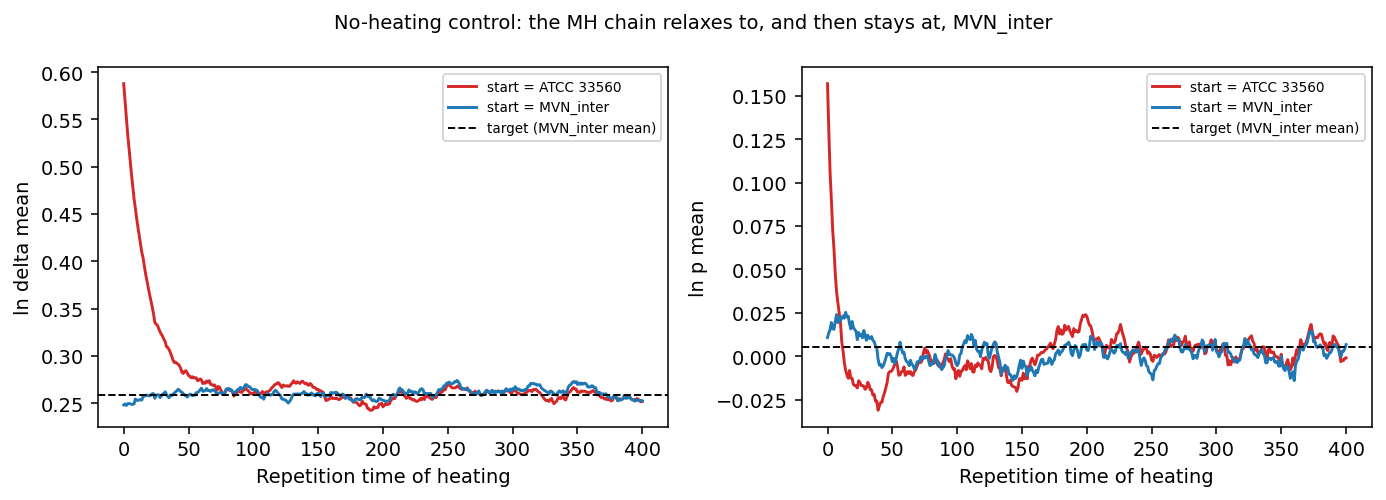

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10,3.6), dpi=140)
for a, col, nm in zip(ax, ['logdelta_mean','logpower_mean'], ['ln delta','ln p']):
    a.plot(s_atcc['cycle'],  s_atcc[col],  label='start = ATCC 33560', color='C3')
    a.plot(s_inter['cycle'], s_inter[col], label='start = MVN_inter',  color='C0')
    a.axhline(mu_t[0] if 'delta' in col else mu_t[1], ls='--', c='k', lw=1,
              label='target (MVN_inter mean)')
    a.set_xlabel('Repetition time of heating'); a.set_ylabel(f'{nm} mean'); a.legend(fontsize=7)
fig.suptitle('No-heating control: the MH chain relaxes to, and then stays at, MVN_inter', fontsize=10)
plt.tight_layout(); plt.savefig('Evo_Fig/FigS1_algorithm_validation.pdf', bbox_inches='tight'); plt.show()

              recovered            target
mean ln d    0.2519             0.2590
mean ln p   -0.0010             0.0053
sd   ln d    0.2588             0.2580
sd   ln p    0.3080             0.3061
corr        -0.4344            -0.4553

KS test of Mahalanobis^2 vs chi2(2):  D = 0.0277,  p = 0.092
(p > 0.05  =>  the sampler recovers MVN_inter; the MH implementation is correct)


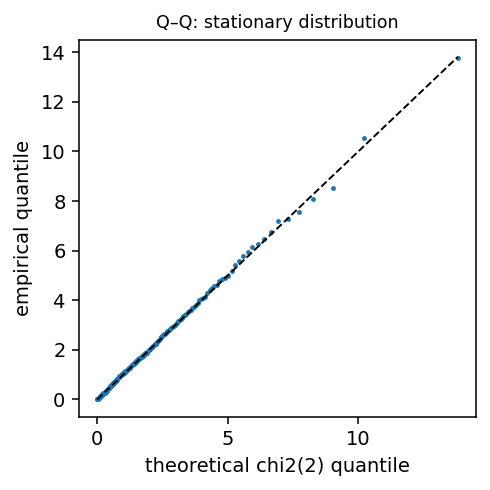

In [7]:
# ---- quantitative check on the recovered stationary distribution -------------
X = final_params(val_atcc)      # relaxed from ATCC, no heating, after 400 cycles
emp_mu, emp_cov = X.mean(axis=0), np.cov(X.T)

print('              recovered            target')
print(f'mean ln d   {emp_mu[0]: .4f}            {mu_t[0]: .4f}')
print(f'mean ln p   {emp_mu[1]: .4f}            {mu_t[1]: .4f}')
print(f'sd   ln d   {np.sqrt(emp_cov[0,0]): .4f}            {np.sqrt(cov_t[0,0]): .4f}')
print(f'sd   ln p   {np.sqrt(emp_cov[1,1]): .4f}            {np.sqrt(cov_t[1,1]): .4f}')
r_e = emp_cov[0,1]/np.sqrt(emp_cov[0,0]*emp_cov[1,1])
r_t = cov_t[0,1]/np.sqrt(cov_t[0,0]*cov_t[1,1])
print(f'corr        {r_e: .4f}            {r_t: .4f}')

# Mahalanobis distances must follow chi2 with 2 df if the target is recovered
Xc  = X - mu_t
md2 = np.einsum('ij,jk,ik->i', Xc, np.linalg.inv(cov_t), Xc)
ks  = stats.kstest(md2, 'chi2', args=(2,))
print(f'\nKS test of Mahalanobis^2 vs chi2(2):  D = {ks.statistic:.4f},  p = {ks.pvalue:.3f}')
print('(p > 0.05  =>  the sampler recovers MVN_inter; the MH implementation is correct)')

fig, ax = plt.subplots(figsize=(3.6,3.6), dpi=140)
q = np.linspace(0.001,0.999,200)
ax.plot(stats.chi2.ppf(q,2), np.quantile(md2,q), '.', ms=3)
lim = [0, stats.chi2.ppf(0.999,2)]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('theoretical chi2(2) quantile'); ax.set_ylabel('empirical quantile')
ax.set_title('Q–Q: stationary distribution', fontsize=9)
plt.tight_layout(); plt.savefig('Evo_Fig/FigS2_QQ_stationary.pdf', bbox_inches='tight'); plt.show()

---
## Part 3 — Sensitivity to **intra**-strain covariance
### → Reviewer #3 (*"We would suggest that the authors run a sensitivity analysis on within-cell variability"*) + Reviewer #2 (L156)

R3 correctly identified that the *speed* of the simulated shift is governed by the balance
between (i) how far parameters can drift per generation (COV$_{\rm intra}$) and
(ii) the survival margin set by the heating time.

`sd_scale_within` multiplies the intra-strain **standard deviations**
(so COV$_{\rm intra}$ is scaled by the square). `1.0` = the published run.

In [8]:
SD_W = [0.25, 0.5, 1.0, 2.0, 4.0]
res_w = {}
for s in SD_W:
    for lab, t in [('2log',T['2log']), ('4log',T['4log']), ('6log',T['6log'])]:
        h = run_batch(samples, t_heating=t, sim_num=2000, processor_num=NPROC,
                      revo_num=REVO_NUM, cell_count=CELL, n_carry=1, L_para=1.0,
                      init_mode='inter', sd_scale_within=s)
        res_w[(s,lab)] = summarise(h, REVO_NUM)
    print(f'sd_scale_within = {s} done')

sd_scale_within = 0.25 done
sd_scale_within = 0.5 done
sd_scale_within = 1.0 done
sd_scale_within = 2.0 done
sd_scale_within = 4.0 done


 sd_scale_within heating  final ln delta  final ln p  cycles to converge  survival ratio
           0.250    2log           0.400       0.320                  88           0.976
           0.500    2log           0.491       0.486                  71           0.989
           1.000    2log           0.498       0.509                  29           0.996
           2.000    2log           0.504       0.498                  86           0.999
           4.000    2log           0.499       0.487                  18           1.000
           0.250    4log           0.675       0.405                  89           0.309
           0.500    4log           0.738       0.589                  61           0.391
           1.000    4log           0.759       0.627                  76           0.515
           2.000    4log           0.767       0.618                  77           0.703
           4.000    4log           0.764       0.610                  92           0.858
           0.250    6

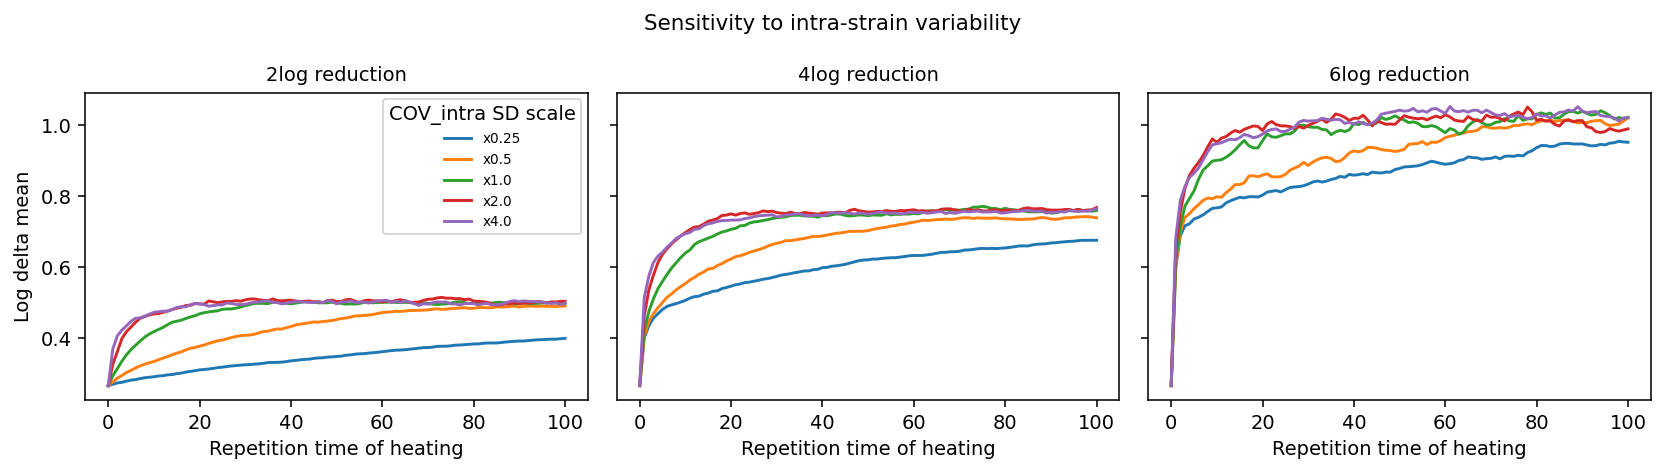

In [9]:
rows=[]
for (s,lab),sm in res_w.items():
    rows.append({'sd_scale_within': s, 'heating': lab,
                 'final ln delta': sm['logdelta_mean'].iloc[-1],
                 'final ln p'    : sm['logpower_mean'].iloc[-1],
                 'cycles to converge': convergence_cycle(sm),
                 'survival ratio': sm['survival_ratio'].iloc[-1]})
tab_w = pd.DataFrame(rows).sort_values(['heating','sd_scale_within'])
print(tab_w.to_string(index=False, float_format='%.3f'))
tab_w.to_csv('Evo_Fig/Table_S3_sensitivity_intra.csv', index=False)

fig, ax = plt.subplots(1,3, figsize=(12,3.4), dpi=140, sharey=True)
for a,lab in zip(ax, ['2log','4log','6log']):
    for s in SD_W:
        a.plot(res_w[(s,lab)]['cycle'], res_w[(s,lab)]['logdelta_mean'], label=f'x{s}')
    a.set_title(f'{lab} reduction', fontsize=10); a.set_xlabel('Repetition time of heating')
ax[0].set_ylabel('Log delta mean'); ax[0].legend(title='COV_intra SD scale', fontsize=7)
fig.suptitle('Sensitivity to intra-strain variability', fontsize=11)
plt.tight_layout(); plt.savefig('Evo_Fig/FigS3_sensitivity_intra.pdf', bbox_inches='tight'); plt.show()

---
## Part 4 — Sensitivity to **inter**-strain covariance
### → Reviewer #2 (L156)

COV$_{\rm inter}$ is the *"gravity of the species"*: it bounds how far the chain can be pulled
away from the species mean. Widening it should allow larger shifts; narrowing it should
suppress them.

In [10]:
SD_B = [0.5, 0.75, 1.0, 1.5, 2.0]
res_b = {}
for s in SD_B:
    for lab, t in [('2log',T['2log']), ('4log',T['4log']), ('6log',T['6log'])]:
        h = run_batch(samples, t_heating=t, sim_num=2000, processor_num=NPROC,
                      revo_num=REVO_NUM, cell_count=CELL, n_carry=1, L_para=1.0,
                      init_mode='inter', sd_scale_between=s)
        res_b[(s,lab)] = summarise(h, REVO_NUM)
    print(f'sd_scale_between = {s} done')

rows=[]
for (s,lab),sm in res_b.items():
    rows.append({'sd_scale_between': s, 'heating': lab,
                 'final ln delta': sm['logdelta_mean'].iloc[-1],
                 'shift from cycle 0': sm['logdelta_mean'].iloc[-1]-sm['logdelta_mean'].iloc[0],
                 'cycles to converge': convergence_cycle(sm),
                 'survival ratio': sm['survival_ratio'].iloc[-1]})
tab_b = pd.DataFrame(rows).sort_values(['heating','sd_scale_between'])
print(tab_b.to_string(index=False, float_format='%.3f'))
tab_b.to_csv('Evo_Fig/Table_S4_sensitivity_inter.csv', index=False)

sd_scale_between = 0.5 done
sd_scale_between = 0.75 done
sd_scale_between = 1.0 done
sd_scale_between = 1.5 done
sd_scale_between = 2.0 done
 sd_scale_between heating  final ln delta  shift from cycle 0  cycles to converge  survival ratio
            0.500    2log           0.354               0.090                  17           1.000
            0.750    2log           0.433               0.168                  31           1.000
            1.000    2log           0.498               0.230                  29           0.996
            1.500    2log           0.600               0.328                  60           0.954
            2.000    2log           0.699               0.423                  89           0.887
            0.500    4log           0.516               0.253                  96           0.168
            0.750    4log           0.655               0.389                  80           0.463
            1.000    4log           0.759               0.491              

---
## Part 5 — Sensitivity to the carry-over parameter **n**
### → Reviewer #2 (L214) and Reviewer #3 (*"single-individual bottleneck at each generation"*)

Biological rationale for **n = 1**: contamination between cycles is initiated by a *minute*
population carried over in droplets or by surface contact. n = 1 is the **maximal-bottleneck /
worst-case** setting for lineage divergence — and it is the only setting that is
computationally tractable at 10,000 x 100 cycles.

Here n is generalised: n cells are carried over, each regrows to `N_cell/n` daughters, and
n survivors are transferred to the next cycle.  **n = 1 reproduces the published run exactly.**

n_carry = 1 done
n_carry = 10 done
n_carry = 100 done
n_carry = 1000 done
 n_carry heating  final ln delta  final ln p  cycles to converge  survival ratio
       1    2log           0.500       0.509                  31           0.998
      10    2log           0.665       0.889                  94           1.000
     100    2log           0.708       1.024                  48           1.000
    1000    2log           0.730       1.057                  56           1.000
       1    4log           0.771       0.620                  93           0.526
      10    4log           0.959       1.094                  81           0.939
     100    4log           1.020       1.243                  55           0.991
    1000    4log           1.043       1.286                  62           0.997
       1    6log           1.026       0.685                  97           0.045
      10    6log           1.250       1.166                  93           0.163
     100    6log           1.297   

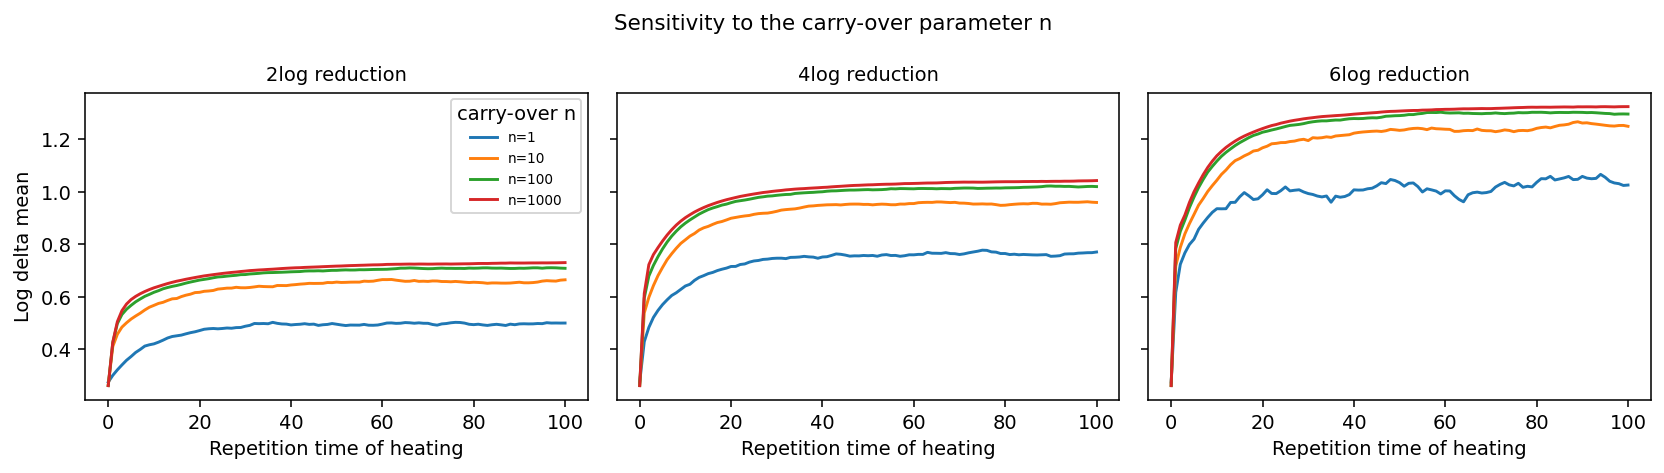

In [11]:
N_CARRY = [1, 10, 100, 1000]
res_n = {}
for n in N_CARRY:
    for lab, t in [('2log',T['2log']), ('4log',T['4log']), ('6log',T['6log'])]:
        h = run_batch(samples, t_heating=t, sim_num=1000, processor_num=NPROC,
                      revo_num=REVO_NUM, cell_count=CELL, n_carry=n, L_para=1.0,
                      init_mode='inter')
        res_n[(n,lab)] = summarise(h, REVO_NUM)
    print(f'n_carry = {n} done')

rows=[]
for (n,lab),sm in res_n.items():
    rows.append({'n_carry': n, 'heating': lab,
                 'final ln delta': sm['logdelta_mean'].iloc[-1],
                 'final ln p'    : sm['logpower_mean'].iloc[-1],
                 'cycles to converge': convergence_cycle(sm),
                 'survival ratio': sm['survival_ratio'].iloc[-1]})
tab_n = pd.DataFrame(rows).sort_values(['heating','n_carry'])
print(tab_n.to_string(index=False, float_format='%.3f'))
tab_n.to_csv('Evo_Fig/Table_S5_sensitivity_carryover.csv', index=False)

fig, ax = plt.subplots(1,3, figsize=(12,3.4), dpi=140, sharey=True)
for a,lab in zip(ax, ['2log','4log','6log']):
    for n in N_CARRY:
        a.plot(res_n[(n,lab)]['cycle'], res_n[(n,lab)]['logdelta_mean'], label=f'n={n}')
    a.set_title(f'{lab} reduction', fontsize=10); a.set_xlabel('Repetition time of heating')
ax[0].set_ylabel('Log delta mean'); ax[0].legend(title='carry-over n', fontsize=7)
fig.suptitle('Sensitivity to the carry-over parameter n', fontsize=11)
plt.tight_layout(); plt.savefig('Evo_Fig/FigS4_sensitivity_carryover.pdf', bbox_inches='tight'); plt.show()

---
## Part 6 — The likelihood-ratio exponent `L_para`
### → Reviewer #3 (*"the authors appear to run in the python code a sensitivity analysis on the exponent applied to the likelihood ratio ... the manuscript text is not explicit enough"*)

**The reviewer found `L_para` in the code and we must explain it.** It is the exponent in the
Metropolis acceptance probability:

$$\Pr(\text{accept}) = \min\!\left(1,\; \mathrm{LR}^{\,L}\right),\qquad
\mathrm{LR}=\frac{f_{\rm MVN_{inter}}(\text{candidate})}{f_{\rm MVN_{inter}}(\text{current})}$$

* **L = 1** (the published setting) → standard MH; the stationary distribution is exactly MVN$_{\rm inter}$.
* **L = 0** → no inter-strain constraint; pure unbounded diffusion (no "species gravity").
* **L > 1** → a *stronger* constraint; the stationary distribution is $\propto$ MVN$_{\rm inter}^{\,L}$, i.e. a
  narrower version of the species distribution.

So `L_para` is a **tempering parameter on the species-level constraint**. The paper uses
**L = 1 throughout**; the exploratory runs in the old notebook were a robustness check.
We now report it as an explicit sensitivity analysis (and state in the Methods that L = 1).

In [12]:
L_VALS = [0.0, 0.5, 1.0, 2.0]
res_L = {}
for L in L_VALS:
    for lab, t in [('none',T['none']), ('4log',T['4log']), ('6log',T['6log'])]:
        h = run_batch(samples, t_heating=t, sim_num=1000, processor_num=NPROC,
                      revo_num=REVO_NUM, cell_count=CELL, n_carry=1, L_para=L,
                      init_mode='inter')
        res_L[(L,lab)] = summarise(h, REVO_NUM)
    print(f'L_para = {L} done')

rows=[]
for (L,lab),sm in res_L.items():
    rows.append({'L_para': L, 'heating': lab,
                 'final ln delta': sm['logdelta_mean'].iloc[-1],
                 'final sd ln delta': sm['logdelta_sd'].iloc[-1],
                 'survival ratio': sm['survival_ratio'].iloc[-1]})
tab_L = pd.DataFrame(rows).sort_values(['heating','L_para'])
print(tab_L.to_string(index=False, float_format='%.3f'))
tab_L.to_csv('Evo_Fig/Table_S6_sensitivity_Lpara.csv', index=False)
print('\nNOTE for the Methods: L = 1 in every result reported in the paper.')
print('L = 0 (no heating) should show unbounded diffusion -> a diagnostic that the')
print('inter-strain constraint really is what stabilises the chain.')

L_para = 0.0 done
L_para = 0.5 done
L_para = 1.0 done
L_para = 2.0 done
 L_para heating  final ln delta  final sd ln delta  survival ratio
  0.000    4log           1.500              0.770           0.575
  0.500    4log           0.884              0.258           0.554
  1.000    4log           0.771              0.194           0.526
  2.000    4log           0.631              0.155           0.429
  0.000    6log           1.804              0.758           0.106
  0.500    6log           1.162              0.242           0.063
  1.000    6log           1.026              0.198           0.045
  2.000    6log           0.814              0.142           0.012
  0.000    none           0.313              1.013           1.000
  0.500    none           0.274              0.332           1.000
  1.000    none           0.267              0.233           1.000
  2.000    none           0.261              0.166           1.000

NOTE for the Methods: L = 1 in every result reported in 

---
## Part 7 — Is 10,000 replicates enough?
### → Reviewer #1 (rigour) — a cheap but persuasive robustness check

In [13]:
rows=[]
for N in [1000, 2500, 5000, 10000, 20000]:
    h = run_batch(samples, t_heating=T['6log'], sim_num=N, processor_num=NPROC,
                  revo_num=REVO_NUM, cell_count=CELL, init_mode='inter')
    sm = summarise(h, REVO_NUM)
    rows.append({'replicates': N,
                 'final ln delta': sm['logdelta_mean'].iloc[-1],
                 'final ln p'    : sm['logpower_mean'].iloc[-1],
                 'survival ratio': sm['survival_ratio'].iloc[-1]})
    print(N, 'done')
tab_mc = pd.DataFrame(rows)
print(tab_mc.to_string(index=False, float_format='%.4f'))
tab_mc.to_csv('Evo_Fig/Table_S7_MC_convergence.csv', index=False)
print('\n=> if the columns are stable from ~5,000 onwards, 10,000 replicates are ample.')

1000 done
2500 done
5000 done
10000 done
20000 done
 replicates  final ln delta  final ln p  survival ratio
       1000          1.0259      0.6845          0.0450
       2500          1.0286      0.7297          0.0448
       5000          1.0229      0.6847          0.0462
      10000          1.0146      0.6867          0.0468
      20000          1.0123      0.6841          0.0476

=> if the columns are stable from ~5,000 onwards, 10,000 replicates are ample.


---
## Part 8 — Quantitative convergence rates
### → Reviewer #2 / #3 (*"this important result could be emphasized and quantified more clearly"*)

Replaces the eyeballed "20–30 cycles" statements in the Results with hard numbers.

In [14]:
res_main = {}
for init, lab_i, ilog in [('fixed','ATCC 33560',ATCC), ('inter','MVN_inter',None)]:
    for lab, t in T.items():
        h = run_batch(samples, t_heating=t, sim_num=SIM_NUM, processor_num=NPROC,
                      revo_num=REVO_NUM, cell_count=CELL, n_carry=1, L_para=1.0,
                      init_mode=init, init_logpara=ilog)
        res_main[(lab_i,lab)] = summarise(h, REVO_NUM)
    print(lab_i, 'done')

rows=[]
for (init,lab),sm in res_main.items():
    rows.append({'initialisation': init, 'heating': lab,
                 'ln delta (0)': sm['logdelta_mean'].iloc[0],
                 'ln delta (100)': sm['logdelta_mean'].iloc[-1],
                 'cycles to converge (delta)': convergence_cycle(sm,'logdelta_mean'),
                 'cycles to converge (p)': convergence_cycle(sm,'logpower_mean'),
                 'IQR ln delta (100)': np.nan,
                 'survival ratio (100)': sm['survival_ratio'].iloc[-1]})
tab_c = pd.DataFrame(rows)
print(tab_c.to_string(index=False, float_format='%.3f'))
tab_c.to_csv('Evo_Fig/Table_S8_convergence_rates.csv', index=False)

ATCC 33560 done
MVN_inter done
initialisation heating  ln delta (0)  ln delta (100)  cycles to converge (delta)  cycles to converge (p)  IQR ln delta (100)  survival ratio (100)
    ATCC 33560    none         0.588           0.262                          61                      54                 NaN                 1.000
    ATCC 33560    2log         0.588           0.504                          30                      50                 NaN                 1.000
    ATCC 33560    4log         0.588           0.759                          44                      63                 NaN                 0.982
    ATCC 33560    6log         0.588           0.994                          54                      74                 NaN                 0.197
     MVN_inter    none         0.260           0.261                           0                       0                 NaN                 1.000
     MVN_inter    2log         0.260           0.504                          36       

---
## Part 9 — External check against Berdejo et al. (2024)
### → Reviewer #1 (*"provide some evidence"*)

Berdejo *et al.* (2024, mBio) subjected *Salmonella* Typhimurium to **10** heating–growth cycles
and observed a heritable increase in heat-shock resistance. That is the **only** published
experimental-evolution dataset of this design, and it is the natural external benchmark.

We therefore report what our model predicts **at cycle 10** (not cycle 100) so that the
*direction* and *order of magnitude* of the predicted shift can be compared with a real
experiment. This is a qualitative, cross-species comparison — stated as such — but it is a
genuine, falsifiable, external check, and it is what we can offer without new wet-lab work.

In [15]:
rows=[]
for (init,lab),sm in res_main.items():
    if lab == 'none': continue
    d0, d10 = sm['logdelta_mean'].iloc[0], sm['logdelta_mean'].iloc[10]
    rows.append({'initialisation': init, 'heating': lab,
                 'ln delta (0)': d0, 'ln delta (10)': d10,
                 'shift after 10 cycles': d10-d0,
                 'fold-change in delta': np.exp(d10-d0),
                 'survival ratio (10)': sm['survival_ratio'].iloc[10]})
tab_b10 = pd.DataFrame(rows)
print(tab_b10.to_string(index=False, float_format='%.3f'))
tab_b10.to_csv('Evo_Fig/Table_S9_berdejo_10cycles.csv', index=False)
print('\nCompare the "fold-change in delta" column with the fold increase in heat resistance')
print('reported by Berdejo et al. (2024) after 10 cycles.')

initialisation heating  ln delta (0)  ln delta (10)  shift after 10 cycles  fold-change in delta  survival ratio (10)
    ATCC 33560    2log         0.588          0.535                 -0.053                 0.949                1.000
    ATCC 33560    4log         0.588          0.675                  0.087                 1.091                0.995
    ATCC 33560    6log         0.588          0.860                  0.272                 1.312                0.231
     MVN_inter    2log         0.260          0.416                  0.156                 1.169                0.992
     MVN_inter    4log         0.260          0.640                  0.381                 1.464                0.523
     MVN_inter    6log         0.260          0.898                  0.638                 1.893                0.053

Compare the "fold-change in delta" column with the fold increase in heat resistance
reported by Berdejo et al. (2024) after 10 cycles.


---
## Part 10 — QMRA linkage: does the parameter shift actually change the risk?
### → Reviewer #3 (*"this manuscript is more of interest from an evolutionary perspective than from a risk assessment perspective"*)

**This is the comment that threatens the paper's fit to *Microbial Risk Analysis*.**
The fix is to stop asserting relevance to QMRA and to *demonstrate* it: push the
converged parameter distribution through a dose–response model and show by how much the
risk estimate changes.

Below, a fixed thermal process is applied to a contaminated portion, and the probability of
illness is computed **(i)** with the *baseline* (present-day) inter-strain distribution and
**(ii)** with the *converged* distribution after 100 cycles of repeated sublethal heating.

> ⚠️ Replace `DOSE_RESPONSE_*` and `N0_LOG` with the values used in Abe et al. (2024) so that
> the numbers are consistent with your own published QMRA.

                       scenario  mean log10 dose  mean P(illness)  P95 P(illness)  risk ratio vs baseline
 baseline (present-day strains)          -0.9335         0.001862        0.007829                       1
after 100 repeated 6-log cycles            1.469           0.1809          0.2901                   97.15


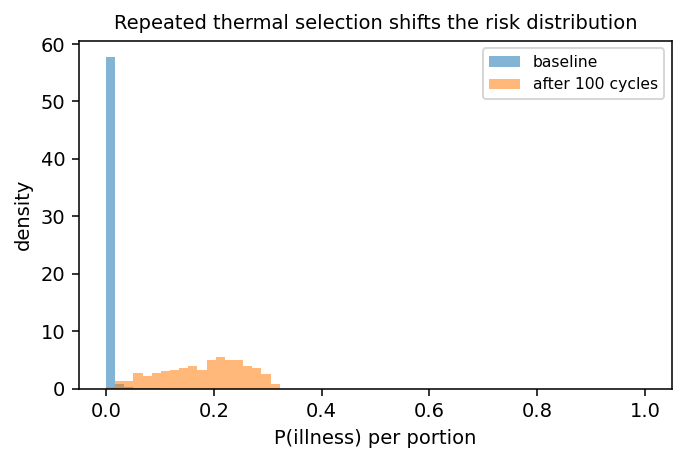

In [16]:
# ---- QMRA inputs (EDIT to match Abe et al., 2024) ----------------------------
N0_LOG   = 2.0        # log10 CFU per portion before heating
PORTION  = 1          # portions consumed
T_PROC   = T['4log']  # the process actually applied in the risk scenario (min)

# Beta-Poisson dose-response for C. jejuni (Medema et al., 1996): alpha, beta
DR_ALPHA, DR_BETA = 0.145, 7.59
def p_ill(dose):
    return 1.0 - (1.0 + dose/DR_BETA)**(-DR_ALPHA)

def risk_from_params(params):
    d, p = np.exp(params[:,0]), np.exp(params[:,1])
    R    = log_reduction(T_PROC, d, p)              # log10 reduction achieved
    dose = np.maximum(10**(N0_LOG - R), 0.0) * PORTION
    return p_ill(dose), dose

# ---- (i) baseline: today's inter-strain distribution -------------------------
base = np.column_stack([samples['Paras0_between'][:,0], samples['Paras0_between'][:,1]])
rng  = np.random.default_rng(0)
idx  = rng.integers(0, base.shape[0], 20000)
base_draw = np.array([rng.multivariate_normal(samples['Paras0_between'][i],
                                              samples['cov_between'][i]) for i in idx])

# ---- (ii) converged: after 100 cycles of 6-log repeated heating --------------
h6 = run_batch(samples, t_heating=T['6log'], sim_num=SIM_NUM, processor_num=NPROC,
               revo_num=REVO_NUM, cell_count=CELL, init_mode='inter')
conv_draw = final_params(h6)

r_base, dose_base = risk_from_params(base_draw)
r_conv, dose_conv = risk_from_params(conv_draw)

out = pd.DataFrame({
    'scenario': ['baseline (present-day strains)', 'after 100 repeated 6-log cycles'],
    'mean log10 dose': [np.log10(dose_base.mean()+1e-12), np.log10(dose_conv.mean()+1e-12)],
    'mean P(illness)': [r_base.mean(), r_conv.mean()],
    'P95 P(illness)' : [np.percentile(r_base,95), np.percentile(r_conv,95)],
})
out['risk ratio vs baseline'] = out['mean P(illness)'] / out['mean P(illness)'].iloc[0]
print(out.to_string(index=False, float_format='%.4g'))
out.to_csv('Evo_Fig/Table_S10_QMRA_linkage.csv', index=False)

fig, ax = plt.subplots(figsize=(5,3.4), dpi=140)
bins = np.linspace(0,1,60)
ax.hist(r_base, bins=bins, alpha=.55, density=True, label='baseline')
ax.hist(r_conv, bins=bins, alpha=.55, density=True, label='after 100 cycles')
ax.set_xlabel('P(illness) per portion'); ax.set_ylabel('density'); ax.legend(fontsize=8)
ax.set_title('Repeated thermal selection shifts the risk distribution', fontsize=10)
plt.tight_layout(); plt.savefig('Evo_Fig/FigS5_QMRA_linkage.pdf', bbox_inches='tight'); plt.show()

---
## Deliverables produced by this notebook

**Figures (supplementary)**
* `FigS1_algorithm_validation.pdf` — chain relaxes to MVN_inter  → **R1**
* `FigS2_QQ_stationary.pdf` — chi-2 Q–Q of the stationary distribution → **R1**
* `FigS3_sensitivity_intra.pdf` — intra-strain sensitivity → **R3, R2**
* `FigS4_sensitivity_carryover.pdf` — carry-over n → **R2**
* `FigS5_QMRA_linkage.pdf` — risk shift → **R3**

**Tables (supplementary)**
`Table_S1` … `Table_S10` (.csv)

**Also remember to upload** `modified Weibull multi-level MVN.pkl` to the GitHub repo —
Reviewer #3 asked for it explicitly.